In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from scipy.stats import zscore

In [2]:
df = pd.read_csv('Dataset/df_clean.csv')
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1,0,missing,normal,notpresent,notpresent,121.000000,...,44.0,7800.0,5.200000,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4,0,missing,normal,notpresent,notpresent,140.798289,...,38.0,6000.0,4.327763,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.000000,...,31.0,7500.0,3.749499,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.000000,...,32.0,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.000000,...,35.0,7300.0,4.600000,no,no,no,good,no,no,ckd


In [3]:
# Converting Object to Category
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Feature Engineering for CKD

## eGFR Calculation (Estimated Glomerular Filtration Rate)
- eGFR is a standard kidney function score, calculated from serum creatinine, age, sex, and sometimes race.
- Since you don’t have sex/race, use the simplified MDRD formula (for adults):
    - eGFR=186×(sc)^(−1.154)×(age)^(−0.203)

In [4]:
df['eGFR'] = 186 * (df['sc'].clip(lower=0.01))**(-1.154) * (df['age'].clip(lower=1))**(-0.203)

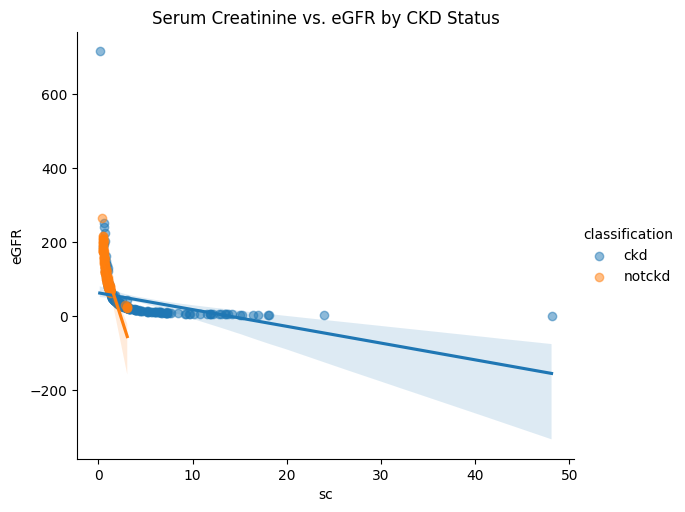

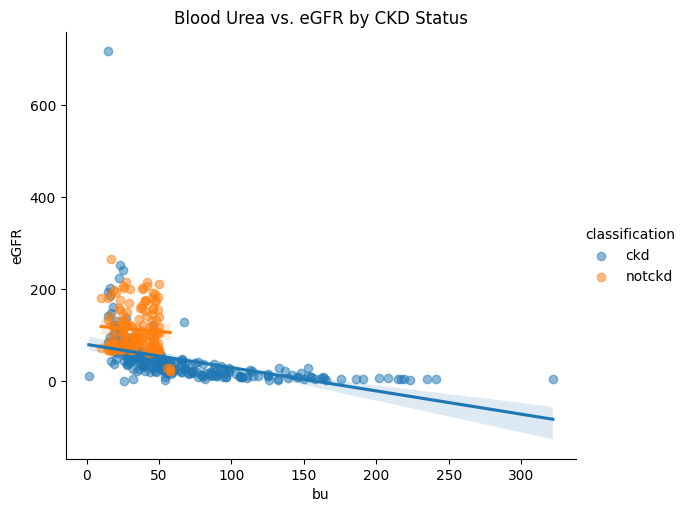

In [5]:
sns.lmplot(x='sc', y='eGFR', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Serum Creatinine vs. eGFR by CKD Status')
plt.show()

sns.lmplot(x='bu', y='eGFR', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Blood Urea vs. eGFR by CKD Status')
plt.show()

## Comorb_Score (Level of Comorbid Conditions in One's Body)
- 0 (none) to 3 (all conditions)
- Each "yes" = 1 point.

In [6]:
df['comorb_score'] = (
    (df['htn'] == 'yes').astype(int) +
    (df['dm'] == 'yes').astype(int) +
    (df['cad'] == 'yes').astype(int)
)

#### Checking trend formed with respect to sc and bu (Expecting positive slope)
- Higher sc/bu => Higher cormorbid condition level

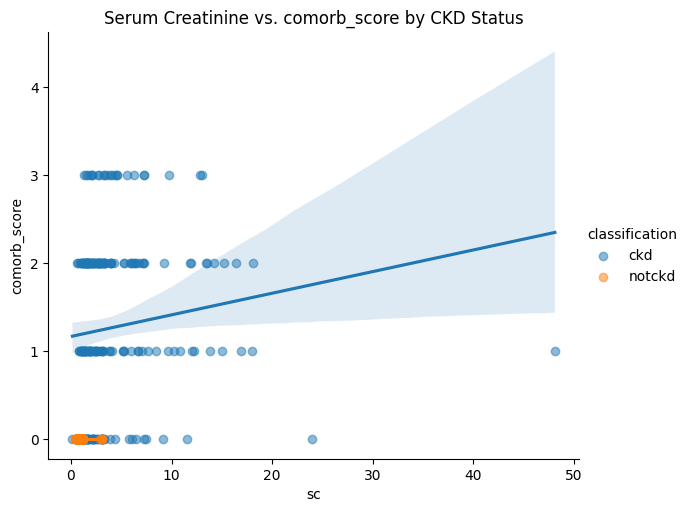

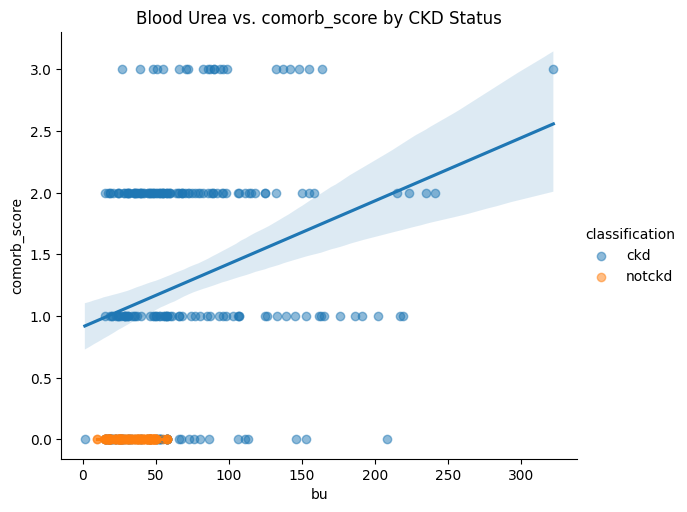

In [7]:
sns.lmplot(x='sc', y='comorb_score', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Serum Creatinine vs. comorb_score by CKD Status')
plt.show()

sns.lmplot(x='bu', y='comorb_score', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Blood Urea vs. comorb_score by CKD Status')
plt.show()

## Anemia Severity Score
- Combine hemo, pcv, rc into a z-score-based severity index.
- Interpretation: Higher value = more severe anemia.

In [8]:
# Calculate z-scores (lower = more severe anemia)
df['anemia_severity'] = -(
    zscore(df['hemo']) +
    zscore(df['pcv']) +
    zscore(df['rc'])
)

#### Checking trend formed with respect to sc and bu (Expecting positive slope)
- Higher sc/bu => Higher anemia severity

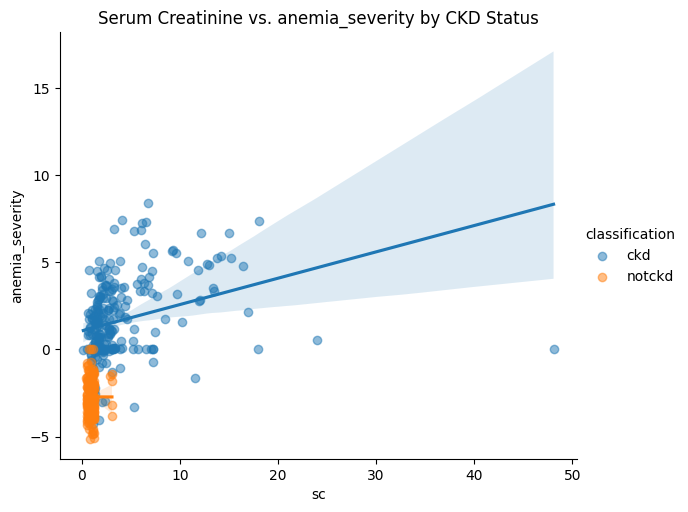

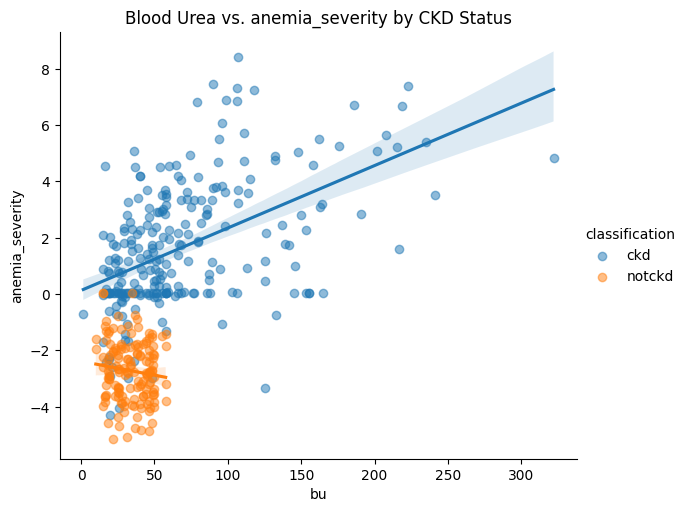

In [9]:
sns.lmplot(x='sc', y='anemia_severity', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Serum Creatinine vs. anemia_severity by CKD Status')
plt.show()

sns.lmplot(x='bu', y='anemia_severity', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Blood Urea vs. anemia_severity by CKD Status')
plt.show()

## Kidney Function Score
- Interpretation: Higher value = worse kidney function.

In [10]:
df['kidney_func_score'] = (
    zscore(df['bu']) +
    zscore(df['sc']) -
    zscore(df['sod'])
)

#### Checking trend formed with respect to sc and bu (Expecting positive slope)
- Higher sc/bu => Higher kidney function score

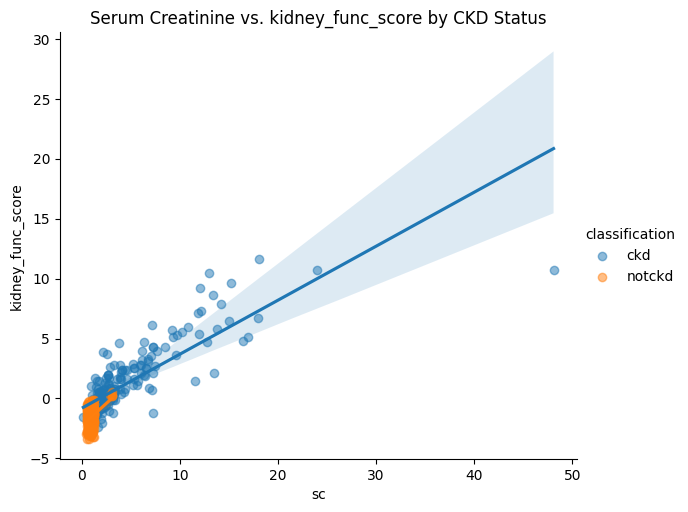

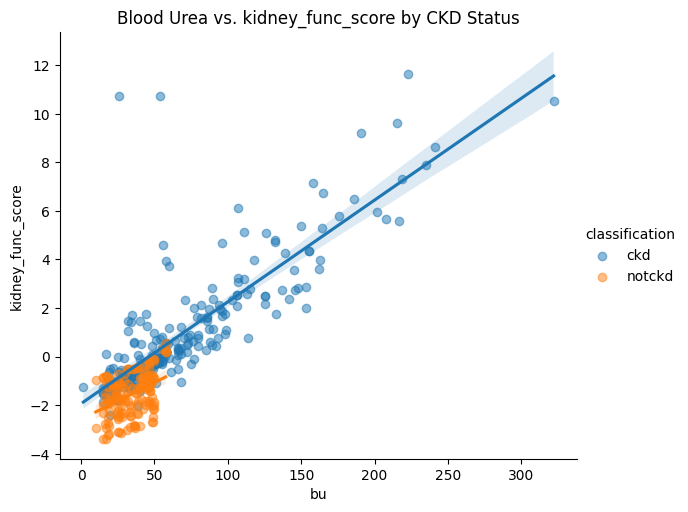

In [11]:
sns.lmplot(x='sc', y='kidney_func_score', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Serum Creatinine vs. kidney_func_score by CKD Status')
plt.show()

sns.lmplot(x='bu', y='kidney_func_score', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Blood Urea vs. kidney_func_score by CKD Status')
plt.show()

## Symptom Severity Score
- Combine appet, pe, ane (each "poor"/"yes" = 1 point).
- Interpretation: Higher score = more severe symptoms.

In [12]:

df['symptom_severity'] = (
    (df['appet'] == 'poor').astype(int) +
    (df['pe'] == 'yes').astype(int) +
    (df['ane'] == 'yes').astype(int)
)

#### Checking trend formed with respect to sc and bu (Expecting positive slope)
- Higher sc/bu => Higher symptom severity level

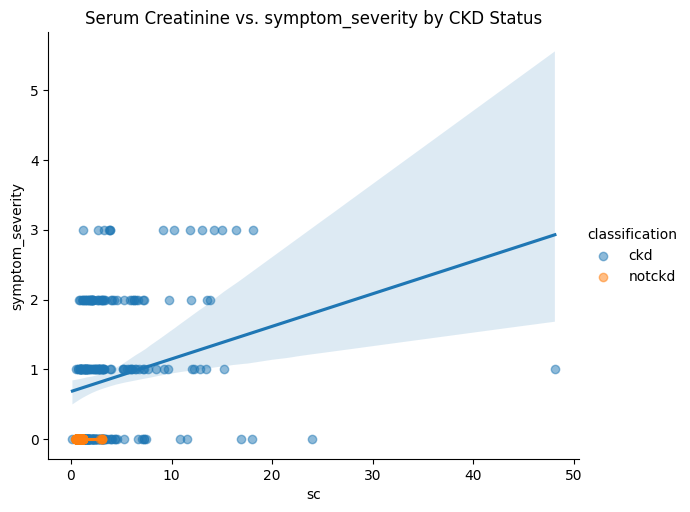

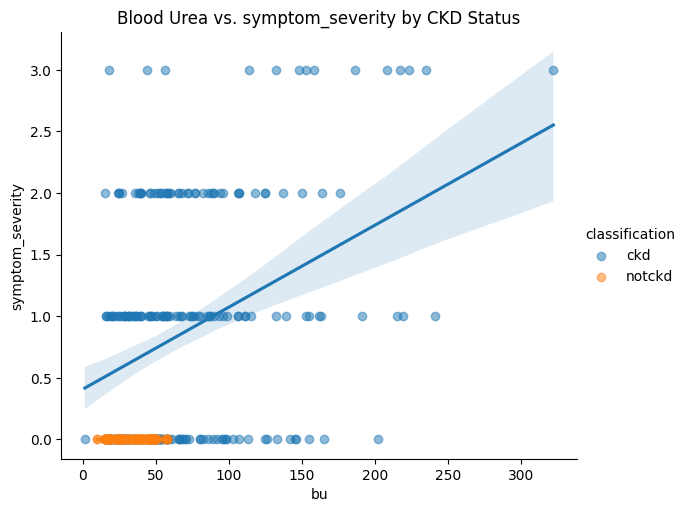

In [13]:
sns.lmplot(x='sc', y='symptom_severity', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Serum Creatinine vs. symptom_severity by CKD Status')
plt.show()

sns.lmplot(x='bu', y='symptom_severity', hue='classification', data=df, aspect=1.2, height=5, scatter_kws={'alpha':0.5})
plt.title('Blood Urea vs. symptom_severity by CKD Status')
plt.show()

## New Set of Numerical Columns

In [14]:
numerical_cols=df.select_dtypes(include=['float64', 'int64']).columns.tolist()

In [15]:
print(numerical_cols)

['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'eGFR', 'comorb_score', 'anemia_severity', 'kidney_func_score', 'symptom_severity']


## Correlation Heatmap for all Variables (After Feature Engineered Columns Have Been Added)

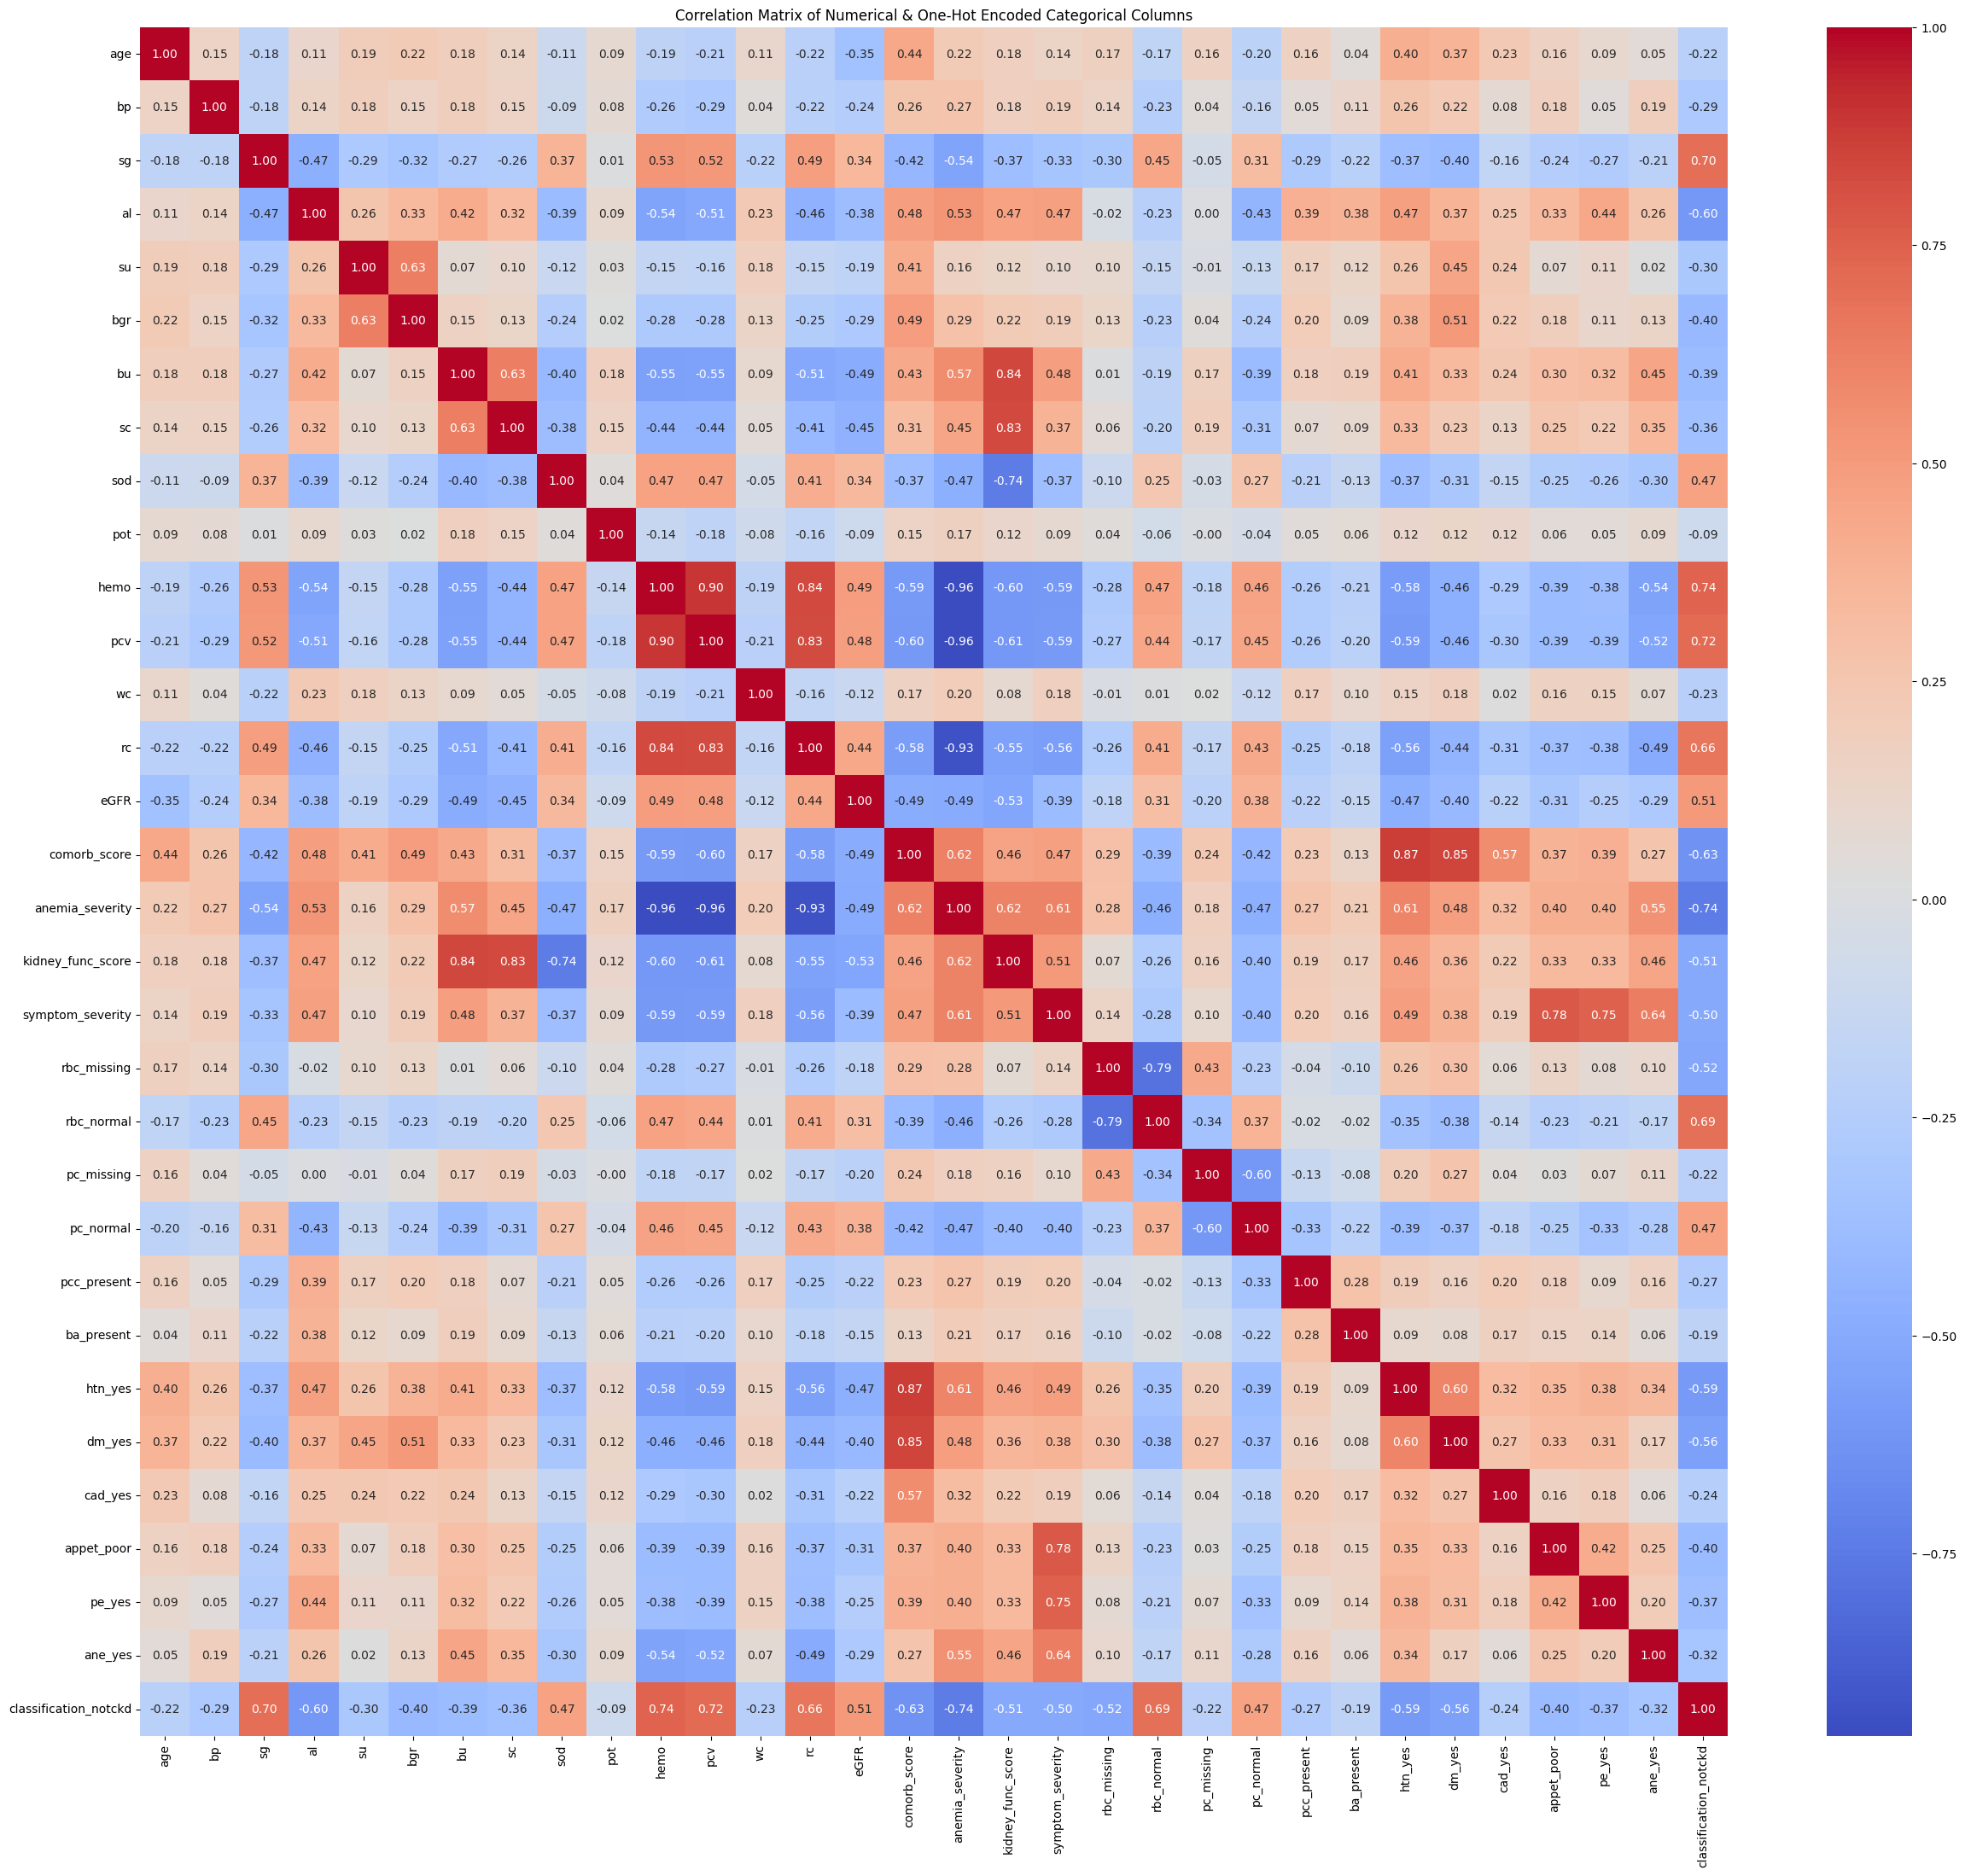

In [16]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['category']).columns

df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)

df_new = pd.concat([df[numerical_cols], df_encoded], axis=1)

corr_matrix = df_new.corr()

plt.figure(figsize=(30, 26))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical & One-Hot Encoded Categorical Columns")
plt.show()


## **1. eGFR**  
- **Positive correlations:**  
  - **0.49 (hemo), 0.48 (pcv), 0.51 (classification_not_ckd)**  
- **Negative correlation:**  
  - **-0.49 (bu), -0.45 (sc), -0.49 (comorb_score), -0.49 (anemia_severity), -0.53 (kidney_func_score), -0.47 (htn_yes)**  
- **Biological Interpretation:**  
  - eGFR decreases with worsening kidney function, which is reflected by higher urea and creatinine. Poor kidney function leads to anemia (low hemoglobin, PCV) and coexists with comorbidities and symptoms. Better eGFR is protective and associated with being classified as not having CKD.


## **2. Comorbidity Score**  
- **Positive correlations:**  
  - **0.49 (bgr), 0.62 (anemia_severity), 0.46 (kidney_func_score), 0.47 (symptom_severity), 0.87 (htn_yes), 0.85 (dm_yes), 0.57 (cad_yes)**  
- **Negative correlation:**  
  - **-0.59 (hemo), -0.60 (pcv), -0.58 (rc), -0.49 (eGFR), -0.63 (classification_notckd))**  
- **Biological Interpretation:**  
  - Higher comorbidity scores indicate the presence of diseases like diabetes, hypertension, and anemia. These are linked with worsening kidney and blood parameters. Comorbidities also increase symptom burden and are strongly associated with CKD classification.


## **3. Anemia Severity**  
- **Positive correlations:**  
  - **0.57 (bu), 0.45 (sc), 0.47 (sod), 0.62 (comorb_score), 0.62 (kidney_func_score), 0.61 (symptom_severity), 0.61 (htn_yes), 0.48 (dm_yes), 0.55 (ane_yes), 0.58 (hemo_bin)**  
- **Negative correlation:**  
  - **-0.54 (sg), -0.96 (hemo), -0.96 (pcv), -0.93 (rc), -0.49 (eGFR), -0.47 (pc_normal), -0.46 (rbc_normal), -0.74 (classification_notckd), -0.54 (hemo_bin))**  
- **Biological Interpretation:**  
  - Anemia severity increases with poor kidney function, as kidneys produce less erythropoietin. Hemoglobin, PCV, and RBC are directly affected. Electrolyte imbalances and comorbidities further exacerbate anemia. CKD patients commonly present with higher anemia severity.

  


## **4. Kidney Function Score**  
- **Positive correlations:**  
  - **0.84 (bu), 0.83 (sc), 0.46 (comorb_score), 0.62 (anemia_severity), 0.51 (symptom_severity), 0.46 (htn_yes), 0.46 (ane_yes), 0.62 (sc_bin), 0.46 (bu_bin)**  
- **Negative correlation:**  
  - **-0.74 (sod), -0.60 (hemo), -0.61 (pcv), -0.55 (rc), -0.53 (eGFR), -0.51 (classification_no_ckd)**  
- **Biological Interpretation:**  
  - The kidney function score reflects deteriorating kidney health. As it worsens, markers like urea and creatinine rise, while sodium and hemoglobin drop. Higher scores are linked with more comorbidities, anemia, and CKD-related symptoms.


## **5. Symptom Severity**  
- **Positive correlations:**  
  - **0.48 (bu), 0.47 (comorb_score), 0.61 (anemia_severity), 0.51 (kidney_func_score), 0.49 (htn_yes), 0.78 (appet_poor), 0.75 (pe_yes), 0.64 (ane_yes)**  
- **Negative correlation:**  
  - **-0.59 (hemo), -0.59 (pcv), -0.56 (rc), -0.50 (classification_not_ckd)**  
- **Biological Interpretation:**  
  - As kidney disease progresses, symptoms like fatigue, appetite loss, and edema increase. These symptoms correlate with anemia, poor kidney function, and comorbid conditions. CKD patients consistently report higher symptom severity.

- Scaling
- Normalisation
- Take different subsets of dataset and test on all models to find best performing
- Train test split
- Model selection from all options
- Metrics

## Distribution of New Numerical Columns

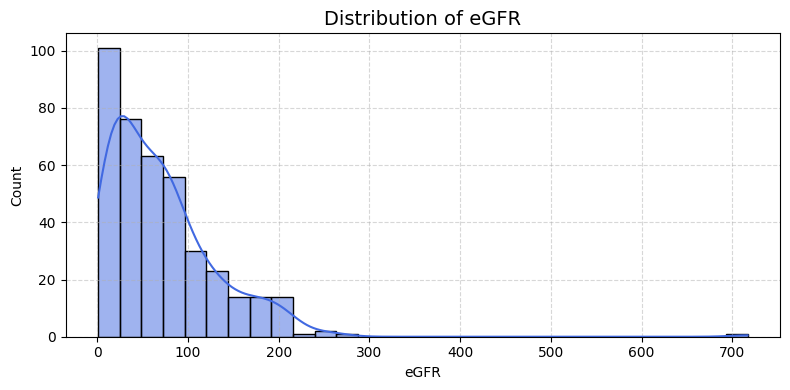

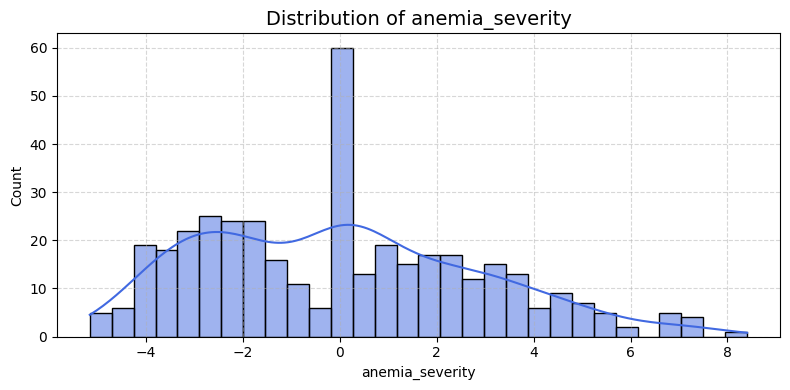

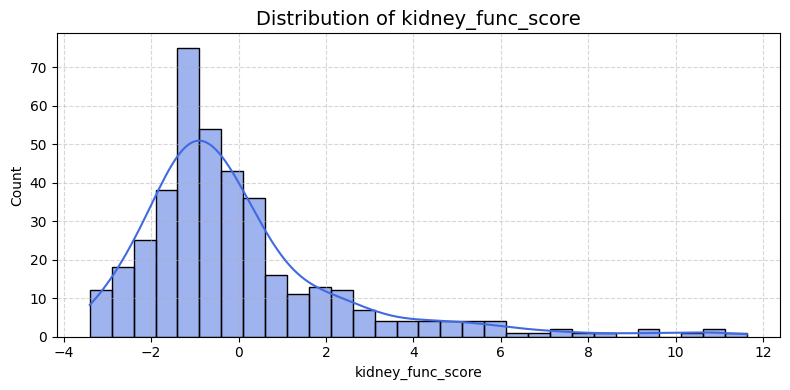

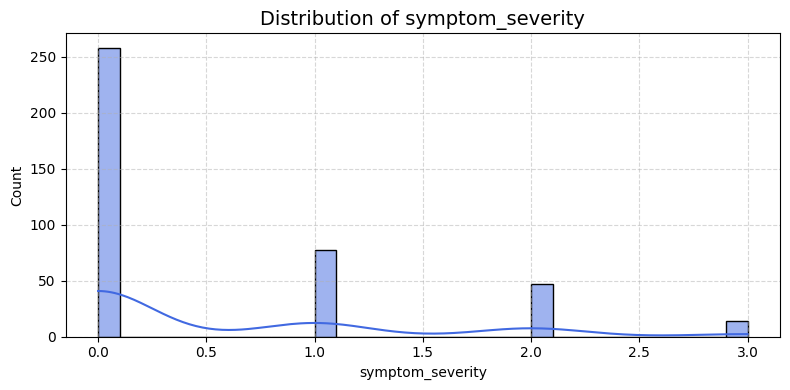

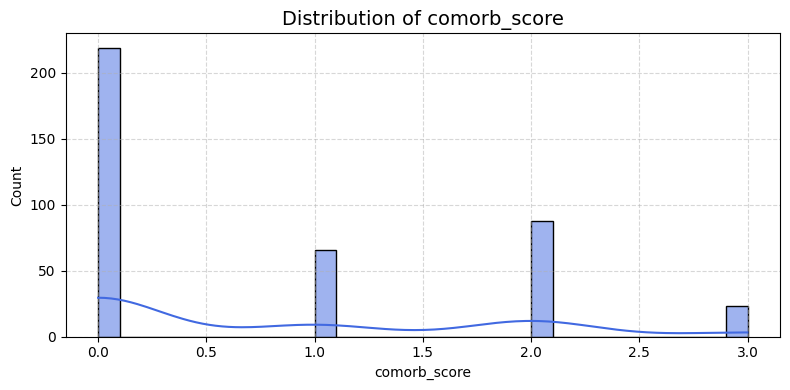

In [17]:
for col in ['eGFR', 'anemia_severity', 'kidney_func_score','symptom_severity','comorb_score']:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='royalblue', bins=30)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'plots/hist_{col}.png')
    plt.show()
    # Interpretation: Look for skewness, multimodality, and outliers.

#### Analysis of Distributions

We observed the following patterns across various features:

>Analysis:
>##### **eGFR**
- **Skewness:** Slightly right-skewed  
- **Modality:** Unimodal (1 peak)  
- **Key Observations:** Most individuals are above mid-40s (45) but under 70.  

>##### **anemia_severity**
- **Skewness:** Slightly right-skewed  
- **Modality:** Bimodal (peaks near -2 and 0)
- **Key Observations:** Sharp spike at 0 possibly indicating a subgroup; most values range between -3 and 4.

>##### **kidney_func_score**
- **Skewness:** Slightly right-skewed  
- **Modality:** Unimodal (1 peak around -1.5)
- **Key Observations:** Majority of values lie between -3 and 2, with a long tail extending toward higher scores.

>##### **symptom_severity**
- **Skewness:** Right-skewed  
- **Modality:** Multimodal (distinct peaks at 0, 1, 2, and 3)
- **Key Observations:** Majority of patients report no symptoms (0), followed by a steep drop for each increasing severity level. Values are discrete and clustered.


>##### **comorb_score**
- **Skewness:** Right-skewed  
- **Modality:** Multimodal (distinct bars at 0, 1, 2, 3)
- **Key Observations:** Most patients have zero comorbidities, but there's a clear step-wise pattern showing others with 1, 2, or 3 conditions. The score appears categorical or count-based.

In [18]:
df.to_csv("Dataset/df_clean_eng.csv", index=False)